In [42]:
from langgraph.graph import StateGraph , START ,END
from dotenv import load_dotenv
from langchain_groq import ChatGroq
from typing import TypedDict
from langgraph.checkpoint.memory  import InMemorySaver

In [49]:
load_dotenv()
import os 

MODEL = "llama-3.3-70b-versatile"

llm = ChatGroq(
    api_key=os.getenv("GROQ_API_KEY"),
    model=MODEL
)

In [50]:
class JokeState(TypedDict):

    topic : str
    joke : str
    expl : str

In [51]:
def generate_joke (state : JokeState):

    prompt = f'''Generate a joke on the topic of {state['topic']} , do not use word ladder in that and make it funny and little personal'''

    joke = llm.invoke(prompt).content

    return {'joke' : joke}

In [52]:
def generate_exp(state : JokeState):

    prompt = f'''Tell me the explanation of the given joke : {state['joke']}'''

    expl = llm.invoke(prompt).content

    return {'expl' : expl}

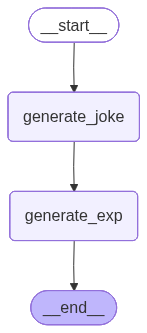

In [53]:
graph = StateGraph(JokeState)

graph.add_node('generate_joke' , generate_joke)
graph.add_node('generate_exp' , generate_exp)

graph.add_edge(START , 'generate_joke')
graph.add_edge('generate_joke' , 'generate_exp')
graph.add_edge('generate_exp' , END)

checkpointer = InMemorySaver()

wf = graph.compile(checkpointer  = checkpointer)
wf

In [54]:
config1 = {'configurable' :{'thread_id' :'1' }}

topicc = input("Tell me the topic on which you want to create a joke")

inp = {'topic' : topicc }

out = wf.invoke(inp , config = config1)

print(out['joke'])

Here's one: Why did I, a joke-teller, just trip over my own joke about the letter 'J'? Because I'm a 'jinx' when it comes to telling jokes – every time I try, I just 'jump' into trouble and face-plant in front of my audience. Guess you could say my joke-telling skills are a little 'jagged'.


In [55]:
wf.get_state(config1)

StateSnapshot(values={'topic': 'j', 'joke': "Here's one: Why did I, a joke-teller, just trip over my own joke about the letter 'J'? Because I'm a 'jinx' when it comes to telling jokes – every time I try, I just 'jump' into trouble and face-plant in front of my audience. Guess you could say my joke-telling skills are a little 'jagged'.", 'expl': 'The explanation of this joke lies in its use of wordplay and self-deprecation. Here\'s a breakdown:\n\n1. **Setup and Punchline**: The joke starts by setting up a situation where the joke-teller trips over their own joke about the letter \'J\'. The punchline is that the joke-teller is a \'jinx\' when it comes to telling jokes, implying that they consistently have bad luck or fail at joke-telling.\n\n2. **Wordplay**: The joke heavily relies on wordplay, using words that start with the letter \'J\' to create a humorous effect. Words like \'jinx\', \'jump\', \'jagged\', and the letter \'J\' itself are all part of this play. This repetition of \'J\

In [56]:
list(wf.get_state_history(config1))

[StateSnapshot(values={'topic': 'j', 'joke': "Here's one: Why did I, a joke-teller, just trip over my own joke about the letter 'J'? Because I'm a 'jinx' when it comes to telling jokes – every time I try, I just 'jump' into trouble and face-plant in front of my audience. Guess you could say my joke-telling skills are a little 'jagged'.", 'expl': 'The explanation of this joke lies in its use of wordplay and self-deprecation. Here\'s a breakdown:\n\n1. **Setup and Punchline**: The joke starts by setting up a situation where the joke-teller trips over their own joke about the letter \'J\'. The punchline is that the joke-teller is a \'jinx\' when it comes to telling jokes, implying that they consistently have bad luck or fail at joke-telling.\n\n2. **Wordplay**: The joke heavily relies on wordplay, using words that start with the letter \'J\' to create a humorous effect. Words like \'jinx\', \'jump\', \'jagged\', and the letter \'J\' itself are all part of this play. This repetition of \'J

In [57]:
config2 = {'configurable' : {'thread_id' :'2'}}
wf.invoke({'topic' : 'Messi'} , config = config2)



{'topic': 'Messi',
 'joke': "Why did Messi bring a pillow to the soccer field? Because he wanted to have a soft defense, and also, his wife told him to have a 'ball' at home, but he took it literally and brought it to the game instead.",
 'expl': 'A joke with a soccer twist. Let\'s break it down:\n\nThe joke is a play on words, with a double meaning. Here\'s the explanation:\n\n1. **Soft defense**: In soccer, a team\'s defense is the players who try to prevent the opposing team from scoring. A "soft defense" is a humorous way of saying a weak or easily penetrable defense. In this joke, Messi brings a pillow to the field, which is a soft object. So, the joke is saying that Messi wants to have a "soft defense" because he\'s literally bringing a soft object (a pillow) to the field.\n\n2. **His wife told him to have a \'ball\' at home**: This is a common idiomatic expression that means to have fun or enjoy oneself. However, in this joke, the phrase "have a ball" is also a reference to a so

In [58]:
list(wf.get_state_history(config2))

[StateSnapshot(values={'topic': 'Messi', 'joke': "Why did Messi bring a pillow to the soccer field? Because he wanted to have a soft defense, and also, his wife told him to have a 'ball' at home, but he took it literally and brought it to the game instead.", 'expl': 'A joke with a soccer twist. Let\'s break it down:\n\nThe joke is a play on words, with a double meaning. Here\'s the explanation:\n\n1. **Soft defense**: In soccer, a team\'s defense is the players who try to prevent the opposing team from scoring. A "soft defense" is a humorous way of saying a weak or easily penetrable defense. In this joke, Messi brings a pillow to the field, which is a soft object. So, the joke is saying that Messi wants to have a "soft defense" because he\'s literally bringing a soft object (a pillow) to the field.\n\n2. **His wife told him to have a \'ball\' at home**: This is a common idiomatic expression that means to have fun or enjoy oneself. However, in this joke, the phrase "have a ball" is also